# Quantum Computing Foundations

Author: Vanessa Knight
Organizational Author / Mentor: ChatGPT (Richard)

## Objective

This notebook introduces the core principles of quantum computing using Qiskit. It covers qubits, quantum circuits, single-qubit gates, measurement, statevectors, the Bloch sphere, and the mathematical intuition needed before studying quantum algorithms.

## Topics Covered

- Creating Quantum Circuits
- Classical Bits vs. Qubits
- Hilbert Space
- Single-Qubit Gates (X, Y, Z, H)
- Measurement
- Statevectors
- Bloch Sphere
- Circuit Visualization

## Learning Goals

By the end of this notebook, I should be able to:

- Explain what a qubit is.
- Build simple quantum circuits in Qiskit.
- Understand the purpose of the X, Y, Z, and H gates.
- Explain superposition.
- Measure qubits correctly.
- Visualize quantum states using the Bloch Sphere.
- Understand the difference between quantum and classical information.

> **Note:** These notes were written while learning quantum computing from first principles. They combine conceptual explanations with practical Qiskit examples and have been refined into a personal reference guide.

# 1. What is a Quantum Circuit?

A **quantum circuit** is the quantum equivalent of a classical computer program.

Instead of manipulating classical bits (0s and 1s), a quantum circuit manipulates **qubits** using **quantum gates**.

A circuit is built from three main components:

- **Qubits** – store quantum information.
- **Quantum Gates** – perform operations on qubits.
- **Measurements** – convert quantum information into classical information.

Quantum circuits are read from **left to right**, with each gate modifying the quantum state before the next operation is applied.

## Key Idea

Think of a quantum circuit as a recipe.

- The qubits are the ingredients.
- The quantum gates are the cooking instructions.
- The measurement tells us the final result.

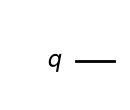

In [43]:
from qiskit import QuantumCircuit

# Create a quantum circuit with one qubit
qc = QuantumCircuit(1)

# Draw the circuit
qc.draw("mpl")

## Notes

This circuit contains:

- **1 qubit**
- **No classical bits**
- **No quantum gates**
- **No measurements**

Every newly created qubit automatically starts in the quantum state

$$
|0\rangle
$$

This is called the **ground state**.

Nothing happens until we begin applying quantum gates.

# 2. Classical Bits vs. Qubits

Classical computers store information using **bits**.

A classical bit can only exist in one of two possible states:

- 0
- 1

Quantum computers store information using **qubits**.

A qubit can exist in:

- $|0\rangle$
- $|1\rangle$
- A **superposition** of both states.

Mathematically, a qubit is written as

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle
$$

where

- $\alpha$ and $\beta$ are called **probability amplitudes**.
- They may be complex numbers.
- They satisfy the normalization condition

$$
|\alpha|^2+|\beta|^2=1
$$

Unlike a classical bit, a qubit is **not simultaneously 0 and 1** in the classical sense. Instead, it exists in a quantum state described by probability amplitudes until it is measured.

## Hilbert Space

Quantum states live in a mathematical vector space called **Hilbert Space**.

You can think of Hilbert Space as the mathematical "home" of quantum states.

Instead of storing only 0s and 1s, quantum information is represented as vectors.

The computational basis states are

$$
|0\rangle=
\begin{bmatrix}
1\\
0
\end{bmatrix}
$$

and

$$
|1\rangle=
\begin{bmatrix}
0\\
1
\end{bmatrix}
$$

Every valid single-qubit state can be represented as a linear combination of these two basis vectors.

> **Intuition:** Just as every point on a graph can be described using x and y coordinates, every single-qubit state can be described using the basis states $|0\rangle$ and $|1\rangle$.

### Key Takeaways

- Classical bits store either **0** or **1**.
- Qubits are vectors that live in **Hilbert Space**.
- Every qubit begins in the state

$$
|0\rangle
$$

unless a quantum gate changes it.

The mathematical description of a qubit is what allows quantum computers to create superposition, interference, and entanglement.

# 3. The X Gate (Quantum NOT)

The **X gate** is the quantum equivalent of a classical **NOT** gate.

It flips the computational basis states:

$$
|0\rangle \longleftrightarrow |1\rangle
$$

Just like a classical NOT gate:

```text
0 → 1
1 → 0
```

If a qubit starts in

$$
|0\rangle
$$

then applying an X gate changes it to

$$
|1\rangle
$$

Likewise,

$$
X|1\rangle = |0\rangle
$$

Applying the X gate twice returns the qubit to its original state:

$$
X^2 = I
$$

where $I$ is the **Identity** operation.

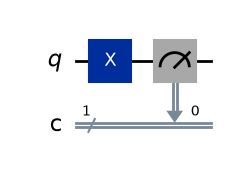

In [44]:
from qiskit import QuantumCircuit

# Create one qubit and one classical bit
qc = QuantumCircuit(1, 1)

# Apply an X gate
qc.x(0)

# Measure the qubit
qc.measure(0, 0)

# Draw the circuit
qc.draw("mpl")

## Understanding the Circuit

```text
q0 ──X──M──

c0 ════════
```

The circuit executes from **left to right**:

1. The qubit begins in the state

$$
|0\rangle
$$

2. The X gate flips it into

$$
|1\rangle
$$

3. The measurement collapses the quantum state and stores the result in the classical bit.

Since the qubit was flipped to $|1\rangle$, repeated executions should always measure

```text
1
```

### Notes

- `QuantumCircuit(1,1)` creates:
  - 1 qubit
  - 1 classical bit

- In

```python
qc.x(0)
```

the `0` refers to **qubit 0**.

- In

```python
qc.measure(0,0)
```

the first `0` refers to **qubit 0**, while the second `0` refers to **classical bit 0**.

This distinction is one of the most common points of confusion when first learning Qiskit.

### Software Engineering Insight

Later, when studying compiler optimization, we'll use the identity

$$
X^2 = I
$$

to simplify circuits.

For example,

```python
qc.x(0)
qc.x(0)
```

has exactly the same effect as doing nothing at all, so the transpiler can safely remove both gates.

# 4. Quantum Measurement

Quantum measurement converts quantum information into classical information.

Until a qubit is measured, it evolves according to the quantum gates applied to it.

Once measured, the quantum state **collapses** into one of the computational basis states:

$$
|0\rangle
$$

or

$$
|1\rangle
$$

The result of the measurement is stored in a **classical bit**.

Unlike classical computers, measurement is generally the **final step** of a quantum algorithm because it destroys the original quantum state.

In [8]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Create one qubit and one classical bit
qc = QuantumCircuit(1, 1)

# Put the qubit into superposition
qc.h(0)

# Measure the qubit
qc.measure(0, 0)

# Run the circuit
backend = AerSimulator()

job = backend.run(qc, shots=1000)

result = job.result()

counts = result.get_counts()

print(counts)

{'0': 516, '1': 484}


## Understanding the Results

Since the Hadamard gate creates an equal superposition,

$$
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

the measurement has an equal probability of producing:

```text
0
```

or

```text
1
```

A typical result might look like:

```text
{'0': 503,
 '1': 497}
```

The exact numbers change each time because quantum measurement is probabilistic.

### Notes

Remember:

Quantum gates operate on **qubits**.

Measurements store results in **classical bits**.

Example:

```python
qc.measure(0,0)
```

means:

- Measure **qubit 0**
- Store the result in **classical bit 0**

This distinction becomes especially important in larger algorithms such as Quantum Teleportation, where qubits and classical bits serve very different purposes.

# 5. The Hadamard Gate (H)

The Hadamard gate is one of the most important gates in quantum computing.

Its primary purpose is to create **superposition**, allowing a qubit to exist in a combination of both basis states simultaneously.

When applied to the computational basis states,

$$
H|0\rangle =
\frac{|0\rangle+|1\rangle}{\sqrt{2}}
$$

and

$$
H|1\rangle =
\frac{|0\rangle-|1\rangle}{\sqrt{2}}
$$

Unlike the X gate, the Hadamard gate does **not** simply flip a qubit.

Instead, it changes the **basis** in which the qubit is represented.

This ability to create superposition is one of the key reasons quantum computers can explore many possibilities simultaneously.

{'0': 481, '1': 519}


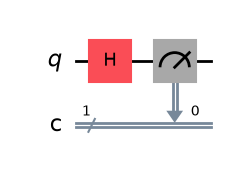

In [46]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

qc = QuantumCircuit(1,1)

# Create superposition
qc.h(0)

# Measure
qc.measure(0,0)

backend = AerSimulator()

job = backend.run(qc, shots=1000)

result = job.result()

counts = result.get_counts()

print(counts)

qc.draw("mpl")

## Understanding Superposition

Initially the qubit is

$$
|0\rangle
$$

After applying a Hadamard gate it becomes

$$
\frac{|0\rangle+|1\rangle}{\sqrt{2}}
$$

This does **not** mean the qubit is "half 0 and half 1."

Instead, it means the quantum state contains probability amplitudes for both outcomes.

When measured, the state collapses and produces either

```text
0
```

or

```text
1
```

with approximately equal probability.

Running the circuit many times should produce roughly

```text
{'0': 500,
 '1': 500}
```

although the exact counts will vary due to randomness.

### Notes

The Hadamard gate is one of the most frequently used gates in quantum computing.

It appears in nearly every major quantum algorithm, including:

- Bell States
- Quantum Teleportation
- Grover's Algorithm
- Quantum Fourier Transform (QFT)
- Shor's Algorithm

A useful identity is

$$
H^2 = I
$$

meaning that applying two Hadamard gates returns the qubit to its original state.

Later we'll also encounter two important identities used by quantum compilers:

$$
HXH = Z
$$

$$
HZH = X
$$

These identities are commonly used during circuit optimization.

# 6. Statevectors

So far, we've observed quantum states by **measuring** them.

However, measurement destroys the quantum state.

To inspect the quantum state **before measurement**, we can use a **Statevector**.

A Statevector is the complete mathematical description of a quantum state.

For a single qubit, it tells us the probability amplitudes associated with the basis states

$$
|0\rangle
$$

and

$$
|1\rangle
$$

Unlike measurement, a Statevector lets us inspect the quantum state without collapsing it.

In [47]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Create a single-qubit circuit
qc = QuantumCircuit(1)

# Create superposition
qc.h(0)

# Compute the quantum state
state = Statevector.from_instruction(qc)

print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


## Understanding the Output

Running the previous cell should produce something similar to

```text
Statevector([0.70710678+0.j,
             0.70710678+0.j],
            dims=(2,))
```

These two numbers are the probability amplitudes of

$$
|0\rangle
$$

and

$$
|1\rangle
$$

respectively.

Since both amplitudes are approximately

$$
\frac{1}{\sqrt{2}}
$$

the probabilities are

$$
\left(\frac{1}{\sqrt{2}}\right)^2=\frac12
$$

meaning there is a 50% chance of measuring

$$
|0\rangle
$$

and a 50% chance of measuring

$$
|1\rangle.
$$

### Notes

A **Statevector** shows the quantum state **before measurement**.

Measurement tells us the final outcome.

Think of them like this:

| Statevector | Measurement |
|-------------|-------------|
| Describes the complete quantum state | Gives one classical outcome |
| No collapse | Causes wavefunction collapse |
| Used for learning and simulation | Used to obtain computation results |

In practice:

- During development and simulation, Statevectors help us understand what our circuit is doing.
- On a real quantum computer, we cannot directly access the Statevector. We only receive measurement results.

# 7. The Bloch Sphere

The **Bloch Sphere** is a graphical representation of a single qubit.

Instead of viewing a qubit as a vector of probability amplitudes, the Bloch Sphere represents its quantum state as a point on the surface of a sphere.

It provides an intuitive way to understand how quantum gates transform qubits.

Every point on the sphere corresponds to a unique single-qubit quantum state.

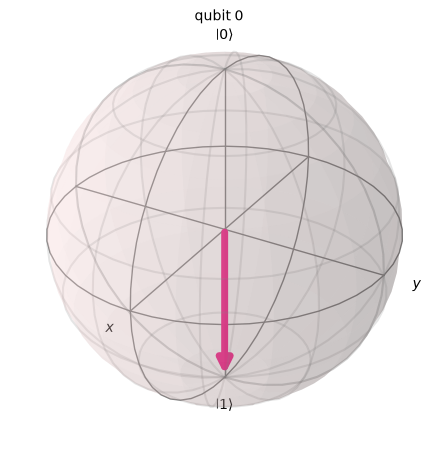

In [13]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Create a single-qubit circuit
qc = QuantumCircuit(1)

# Put the qubit into superposition
qc.h(0)
qc.z(0)
qc.h(0)

# Compute the quantum state
state = Statevector.from_instruction(qc)

# Visualize the Bloch Sphere
plot_bloch_multivector(state)

## Understanding the Bloch Sphere

Some important locations on the Bloch Sphere are:

- North Pole → $|0\rangle$
- South Pole → $|1\rangle$

After applying a Hadamard gate to $|0\rangle$, the qubit moves to the **equator** of the Bloch Sphere.

This represents an equal superposition of

$$
|0\rangle
$$

and

$$
|1\rangle.
$$

The Bloch Sphere helps us visualize how quantum gates rotate a qubit through different quantum states.

### Notes

The Bloch Sphere only works for **one qubit**.

Once multiple qubits become entangled, the system can no longer be represented by a single Bloch Sphere.

Instead, the complete quantum state must be described using a higher-dimensional Statevector.

This is one reason why visualizing large quantum systems quickly becomes difficult.

# 8. Rotation Gates (Rx, Ry, Rz)

Previously, we learned that the X, Y, and Z gates perform 180° rotations about their respective axes on the Bloch Sphere.

The rotation gates allow us to rotate a qubit by **any angle**.

They are:

- Rx — Rotation about the X-axis
- Ry — Rotation about the Y-axis
- Rz — Rotation about the Z-axis

Instead of always rotating 180°, these gates rotate by an angle

$$
\theta
$$

chosen by the programmer.

These gates are especially important in modern quantum algorithms such as Variational Quantum Eigensolvers (VQE), where the rotation angles are optimized automatically.

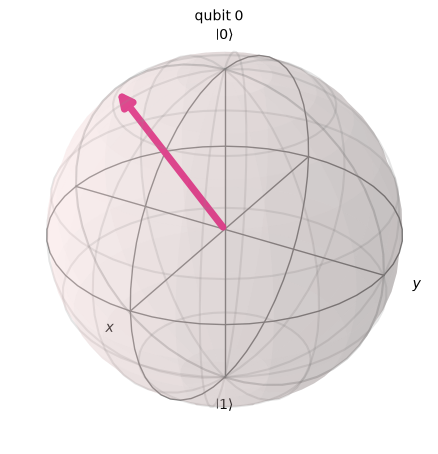

In [ ]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(1)

# Rotate the qubit 90 degrees around the Y-axis
qc.ry(pi/2, 0)

state = Statevector.from_instruction(qc)

plot_bloch_multivector(state)

## Understanding Rotation Gates

Unlike the X, Y, and Z gates, which always rotate by 180°,

rotation gates allow us to choose the angle.

For example,

```python
qc.ry(pi/2, 0)
```

rotates the qubit

- 90° around the Y-axis.

Changing the angle changes the final quantum state.

Examples:

```python
qc.rx(pi/4, 0)
```

45° around X.

```python
qc.ry(pi/2, 0)
```

90° around Y.

```python
qc.rz(pi, 0)
```

180° around Z.

### Notes

Rotation gates are some of the most important gates in quantum computing.

They allow us to create arbitrary quantum states rather than only using fixed rotations.

Later, we will use parameterized versions of these gates:

```python
qc.ry(theta, 0)
qc.rz(phi, 0)
```

where `theta` and `phi` are parameters that can be optimized automatically.

This is the foundation of **Variational Quantum Algorithms (VQE)** and many quantum machine learning models.

# Notebook Summary

Congratulations! You have completed the Quantum Computing Foundations notebook.

## Concepts Learned

✅ Quantum Circuits

✅ Classical Bits vs. Qubits

✅ Hilbert Space

✅ X Gate

✅ Quantum Measurement

✅ Hadamard Gate & Superposition

✅ Statevectors

✅ Bloch Sphere

✅ Rotation Gates (Rx, Ry, Rz)

## Important Identities

$$
X^2 = I
$$

$$
Y^2 = I
$$

$$
Z^2 = I
$$

$$
H^2 = I
$$

Later in this portfolio we'll also use

$$
HXH = Z
$$

$$
HZH = X
$$

during compiler optimization.

## Looking Ahead

Everything in this notebook serves as the foundation for the next notebook:

**Entanglement & Quantum Teleportation**

where we'll learn:

- CNOT Gates
- Bell States
- Entanglement
- Quantum Teleportation

These ideas combine with superposition to create the first genuinely "quantum" algorithms.

# Quick Self-Review

Try answering these questions without looking back.

1. What is a qubit?

2. What is the difference between a qubit and a classical bit?

3. What does the X gate do?

4. What does the Hadamard gate do?

5. What is superposition?

6. What is a Statevector?

7. Why can't we obtain a Statevector from a real quantum computer?

8. What does quantum measurement do?

9. What does the Bloch Sphere represent?

10. Which rotation gate rotates about the Y-axis?

If you can comfortably answer all ten questions, you're ready to move on to Notebook 2.

# Key Takeaways

- Every qubit begins in the state $|0\rangle$.
- Quantum gates manipulate qubits.
- Measurement converts quantum information into classical information.
- The Hadamard gate creates superposition.
- Statevectors describe quantum states before measurement.
- The Bloch Sphere provides an intuitive visualization of a single-qubit state.
- Rotation gates allow arbitrary rotations and are the foundation of many modern quantum algorithms.

These concepts form the building blocks for every quantum algorithm studied later in this portfolio.